# AutoEncoder on Correlation Matrices
In this notebook we train an AutoEncoder to reconstruct correlation matrices stored in `corr_windows_tensor_data_*.pt` and evaluate reconstruction errors (MSE, MAE, Frobenius norm).

In [36]:
from pathlib import Path
import copy
import sys
import json
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Step 1: Load Data
Load correlation matrices from one of the `corr_windows_tensor_data_*.pt` files and optionally select a matrix range `[MATRIX_START, MATRIX_END)`.

In [37]:
MY_FILE_NAME = 'corr_windows_tensor_data_00_20_w724_s10.pt'

if 'google.colab' in sys.modules:
    print('Ambiente rilevato: Google Colab')
    IS_COLAB = True
else:
    print('Ambiente rilevato: Locale (PC)')
    IS_COLAB = False

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    processed_dir = Path('/content/drive/MyDrive/dataset_tesi')
else:
    project_root = Path.cwd().resolve().parent
    processed_dir = project_root / 'data' / 'processed'

selected_file = processed_dir / MY_FILE_NAME

if not selected_file.exists():
    raise FileNotFoundError(
        f"Errore: Il file '{MY_FILE_NAME}' non e stato trovato in: {processed_dir.absolute()}"
    )

print(f'File selezionato: {selected_file.name}')

# Select the matrix range to use: [MATRIX_START, MATRIX_END)
MATRIX_START = 49  # number or None
MATRIX_END = None  # number or None, Example: 500 to use only the first 500 matrices
print(f'Matrix range: [{MATRIX_START}, {MATRIX_END})')

Ambiente rilevato: Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File selezionato: corr_windows_tensor_data_00_20_w724_s10.pt
Matrix range: [49, None)


In [38]:
def load_corr_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        meta = {k: v for k, v in payload.items() if k != 'corr_tensor'}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')

    return corr_tensor.float(), meta


corr_tensor, meta = load_corr_payload(selected_file)
window_ranges = meta.get('window_ranges', None)
window_length = meta.get('window_length', None)
stride = meta.get('stride', None)
tickers = meta.get('tickers', None)

orig_n = corr_tensor.shape[0]
start_idx = 0 if MATRIX_START is None else int(MATRIX_START)
end_idx = orig_n if MATRIX_END is None else int(MATRIX_END)

if not (0 <= start_idx < end_idx <= orig_n):
    raise ValueError(f'Invalid matrix range [{start_idx}, {end_idx}) for dataset size {orig_n}')

corr_tensor = corr_tensor[start_idx:end_idx]
if window_ranges is not None and len(window_ranges) == orig_n:
    window_ranges = window_ranges[start_idx:end_idx]

print(f'corr_tensor shape (selected range): {tuple(corr_tensor.shape)}')
print(f'using matrices: [{start_idx}, {end_idx}) out of {orig_n}')
print(f'dtype: {corr_tensor.dtype}')
print(f'window_length: {window_length}, stride: {stride}')
print(f"#tickers: {len(tickers) if tickers is not None else 'N/A'}")

corr_tensor shape (selected range): (412, 362, 362)
using matrices: [49, 461) out of 461
dtype: torch.float32
window_length: 724, stride: 10
#tickers: 362


## Step 2: Extract Upper Triangular Features
Each correlation matrix is converted to a feature vector using only the upper triangle (excluding diagonal), exactly as done in the PCA notebook.

In [39]:
def upper_triangular_features(corr: torch.Tensor):
    corr_np = corr.numpy()
    n_assets = corr_np.shape[1]
    tri_i, tri_j = np.triu_indices(n_assets, k=1)
    X = corr_np[:, tri_i, tri_j].astype(np.float32)
    return X, tri_i, tri_j, n_assets


X, tri_i, tri_j, n_assets = upper_triangular_features(corr_tensor)
X_tensor = torch.from_numpy(X)

print(f'Number of matrices: {X.shape[0]}')
print(f'Assets per matrix: {n_assets}')
print(f'Upper triangle features: {X.shape[1]}')

Number of matrices: 412
Assets per matrix: 362
Upper triangle features: 65341


## Step 3: Define and Train AutoEncoder
Train a compact fully-connected AutoEncoder on upper-triangle features using MSE loss.
A validation split is used to keep the best model checkpoint.

In [40]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 3):
        super().__init__()
        dimensions = [input_dim, 4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8, latent_dim]

        encoder_layers = []
        for i in range(len(dimensions) - 1):
            encoder_layers.append(nn.Linear(dimensions[i], dimensions[i + 1]))
            if i < len(dimensions) - 2:
                encoder_layers.append(nn.ReLU())
        self.encoder = nn.Sequential(*encoder_layers)

        decoder_dims = dimensions[::-1]
        decoder_layers = []
        for i in range(len(decoder_dims) - 1):
            decoder_layers.append(nn.Linear(decoder_dims[i], decoder_dims[i + 1]))
            if i < len(decoder_dims) - 2:
                decoder_layers.append(nn.ReLU())
            else:
                decoder_layers.append(nn.Tanh())
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [41]:
LATENT_DIM = 3
EPOCHS = 50
LR = 1e-6
WEIGHT_DECAY = 1e-6
BATCH_SIZE = 8

# Cosine annealing scheduler
COSINE_T_MAX = EPOCHS
COSINE_ETA_MIN = 1e-8

VAL_RATIO = 0.2
TEST_RATIO = 0.1
SPLIT_SEED = 42

RUN = 'AE_08_more_layer_wd'
if IS_COLAB:
    run_dir = Path('/content/drive/MyDrive/best_models_tesi/AE')
else:
    run_dir = project_root / 'models' / 'best_models_tesi' / 'AE'

run_output_dir = run_dir / RUN
run_output_dir.mkdir(parents=True, exist_ok=True)
print(f'Results directory: {run_output_dir}')

Results directory: /content/drive/MyDrive/best_models_tesi/AE/AE_08_more_layer_wd


In [42]:
n_total = len(X_tensor)
n_test = max(1, int(TEST_RATIO * n_total))
n_val = max(1, int(VAL_RATIO * n_total))
n_train = n_total - n_val - n_test

if n_train <= 0:
    raise ValueError('Invalid split sizes. Reduce VAL_RATIO and TEST_RATIO.')

dataset = TensorDataset(X_tensor)
train_ds, val_ds, test_ds = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SPLIT_SEED),
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Keep explicit tensors/indices for later reconstruction analysis
train_idx = train_ds.indices
val_idx = val_ds.indices
test_idx = test_ds.indices

X_train_tensor = X_tensor[train_idx]
X_val_tensor = X_tensor[val_idx]
X_test_tensor = X_tensor[test_idx]

print(f'Train samples: {n_train}')
print(f'Validation samples: {n_val}')
print(f'Test samples: {n_test}')

Train samples: 289
Validation samples: 82
Test samples: 41


In [43]:
def validate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for (x_batch,) in loader:
            x_batch = x_batch.to(device)
            x_hat = model(x_batch)
            loss = criterion(x_hat, x_batch)

            batch_size = x_batch.size(0)
            total_loss += loss.item() * batch_size
            total_items += batch_size

    return total_loss / max(total_items, 1)


def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    lr,
    weight_decay,
    cosine_t_max,
    cosine_eta_min,
 ):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=cosine_t_max,
        eta_min=cosine_eta_min,
    )

    history = {'train_loss': [], 'val_loss': [], 'lr': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        seen = 0

        current_lr = float(optimizer.param_groups[0]['lr'])

        for (x_batch,) in train_loader:
            x_batch = x_batch.to(device)
            optimizer.zero_grad()
            x_hat = model(x_batch)
            loss = criterion(x_hat, x_batch)
            loss.backward()
            optimizer.step()

            batch_size = x_batch.size(0)
            running += loss.item() * batch_size
            seen += batch_size

        train_loss = running / max(seen, 1)
        val_loss = validate_epoch(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(current_lr)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())

        print(
            f'Epoch {epoch:03d}/{epochs} | lr={current_lr:.2e} | '
            f'train_loss={train_loss:.6f} | val_loss={val_loss:.6f}'
        )

    model.load_state_dict(best_state)
    return model, history, best_val

In [44]:
model = AutoEncoder(input_dim=X_tensor.shape[1], latent_dim=LATENT_DIM).to(device)

model, history, best_val = train_model(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    cosine_t_max=COSINE_T_MAX,
    cosine_eta_min=COSINE_ETA_MIN,
)

test_loss = validate_epoch(model, test_loader, nn.MSELoss())

print(f'\nBest validation MSE: {best_val:.6f}')
print(f'Test MSE: {test_loss:.6f}')

Epoch 001/50 | lr=1.00e-06 | train_loss=0.150868 | val_loss=0.159929
Epoch 002/50 | lr=9.99e-07 | train_loss=0.150103 | val_loss=0.159086
Epoch 003/50 | lr=9.96e-07 | train_loss=0.149212 | val_loss=0.158066
Epoch 004/50 | lr=9.91e-07 | train_loss=0.148131 | val_loss=0.156827
Epoch 005/50 | lr=9.84e-07 | train_loss=0.146827 | val_loss=0.155335
Epoch 006/50 | lr=9.76e-07 | train_loss=0.145252 | val_loss=0.153547
Epoch 007/50 | lr=9.65e-07 | train_loss=0.143360 | val_loss=0.151381
Epoch 008/50 | lr=9.53e-07 | train_loss=0.141122 | val_loss=0.148878
Epoch 009/50 | lr=9.39e-07 | train_loss=0.138520 | val_loss=0.145989
Epoch 010/50 | lr=9.23e-07 | train_loss=0.135513 | val_loss=0.142604
Epoch 011/50 | lr=9.05e-07 | train_loss=0.132097 | val_loss=0.138854
Epoch 012/50 | lr=8.86e-07 | train_loss=0.128271 | val_loss=0.134629
Epoch 013/50 | lr=8.66e-07 | train_loss=0.124023 | val_loss=0.130032
Epoch 014/50 | lr=8.44e-07 | train_loss=0.119477 | val_loss=0.125062
Epoch 015/50 | lr=8.21e-07 | train

## Step 4: Reconstruct Correlation Matrices and Compute Errors
Decode the upper-triangle features, rebuild full correlation matrices, and evaluate reconstruction quality.

In [45]:
def rebuild_corr_matrices_from_upper(X_upper: np.ndarray, tri_i, tri_j, n_assets: int):
    n_samples = X_upper.shape[0]
    mats = np.zeros((n_samples, n_assets, n_assets), dtype=np.float32)
    mats[:, tri_i, tri_j] = X_upper
    mats[:, tri_j, tri_i] = X_upper
    mats[:, np.arange(n_assets), np.arange(n_assets)] = 1.0
    return mats


def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    diff = original - reconstructed

    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix,
    })

    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats


# Reconstruction on test set
model.eval()
with torch.no_grad():
    X_recon = model(X_test_tensor.to(device)).cpu().numpy()

orig_corr = corr_tensor.numpy()[test_idx]
recon_corr = rebuild_corr_matrices_from_upper(X_recon, tri_i, tri_j, n_assets)

errors_df, errors_stats = reconstruction_errors(orig_corr, recon_corr)

print('Test-set reconstruction error statistics:')
display(errors_stats)

Test-set reconstruction error statistics:


,mean,std,min,median,max
MSE,0.032960,0.024212,0.008023,0.018297,0.077693
MAE,0.142970,0.067814,0.068512,0.104103,0.260069
Frobenius,61.324238,23.926628,32.425346,48.966267,100.902153


Sample index (test set): 0
MSE: 0.021391 | MAE: 0.112931 | Frobenius: 52.944515


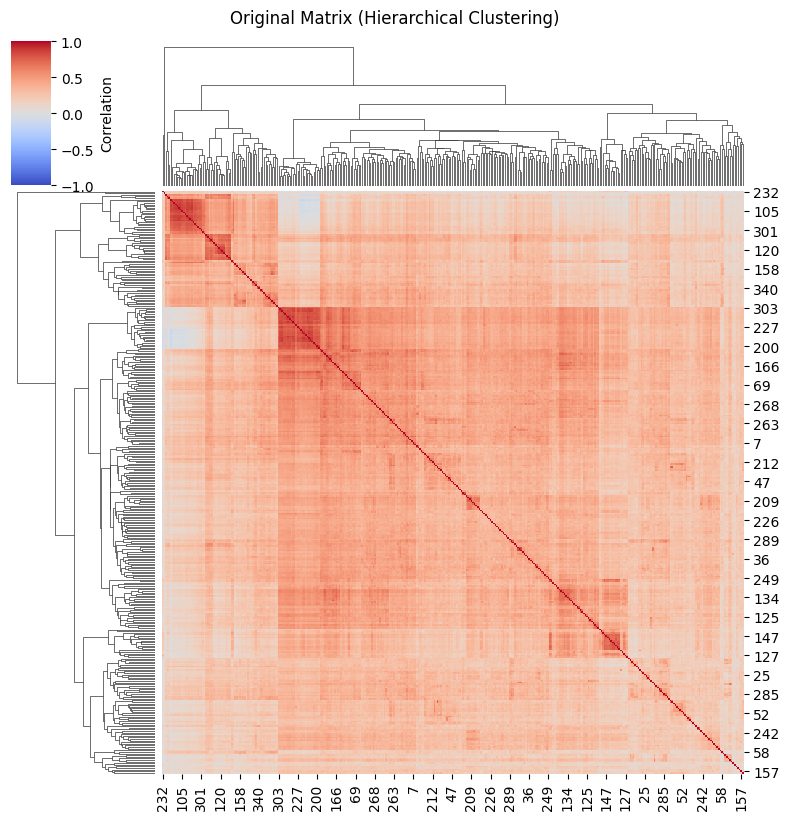

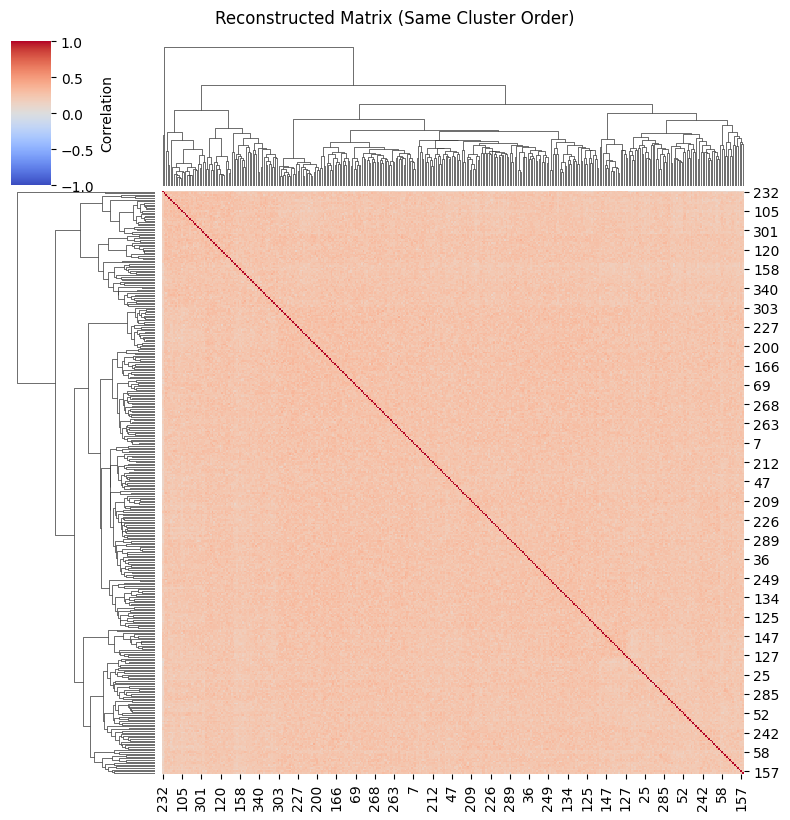

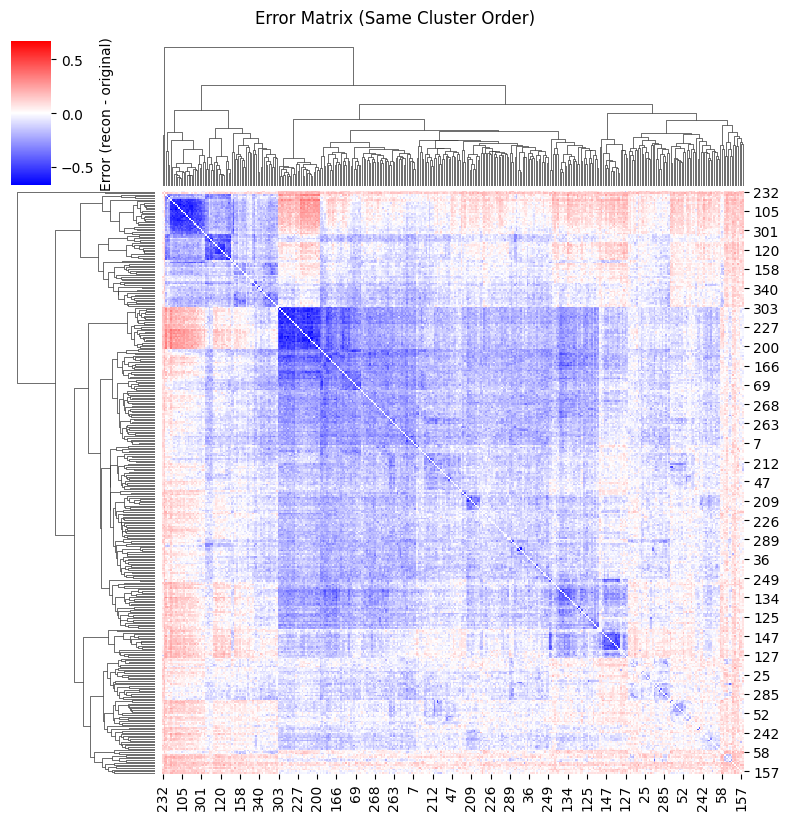

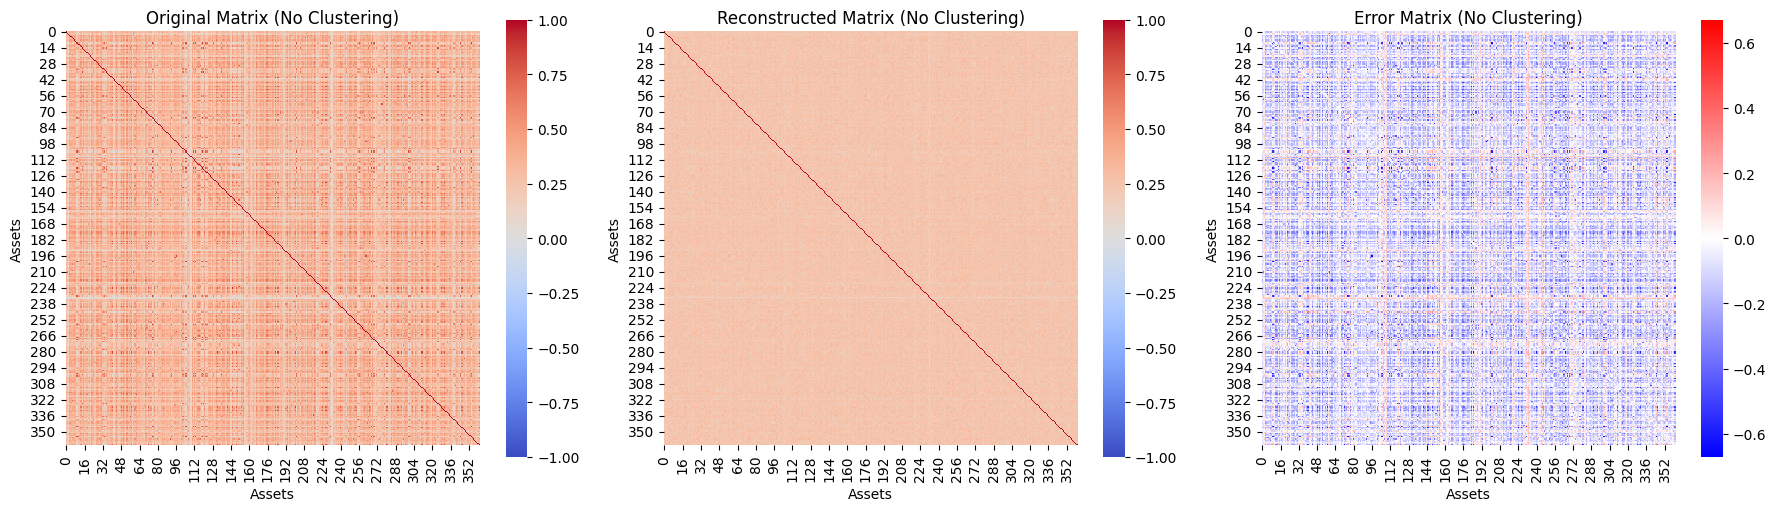

Saved heatmaps for matrix index 0:
 - /content/drive/MyDrive/best_models_tesi/AE/AE_08_more_layer_wd/heatmaps/idx0/ae_cluster_original.png
 - /content/drive/MyDrive/best_models_tesi/AE/AE_08_more_layer_wd/heatmaps/idx0/ae_cluster_reconstructed.png
 - /content/drive/MyDrive/best_models_tesi/AE/AE_08_more_layer_wd/heatmaps/idx0/ae_cluster_error.png
 - /content/drive/MyDrive/best_models_tesi/AE/AE_08_more_layer_wd/heatmaps/idx0/ae_heatmaps_standard.png


In [46]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

sample_idx = 0

if not (0 <= sample_idx < orig_corr.shape[0]):
    raise ValueError(f'sample_idx must be in [0, {orig_corr.shape[0] - 1}]')

orig_mat = orig_corr[sample_idx]
recon_mat = recon_corr[sample_idx]
err_mat = recon_mat - orig_mat

mse_sample = float(np.mean((recon_mat - orig_mat) ** 2))
mae_sample = float(np.mean(np.abs(recon_mat - orig_mat)))
fro_sample = float(np.linalg.norm(recon_mat - orig_mat, ord='fro'))

print(f'Sample index (test set): {sample_idx}')
print(f'MSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')

err_lim = float(np.max(np.abs(err_mat)))
if err_lim == 0:
    err_lim = 1e-6

heatmap_base_dir = run_output_dir / 'heatmaps'
heatmap_base_dir.mkdir(parents=True, exist_ok=True)

# Create subdirectory for this sample index
heatmap_dir = heatmap_base_dir / f'idx{sample_idx}'
heatmap_dir.mkdir(parents=True, exist_ok=True)

# Hierarchical clustering heatmaps
cluster_true = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap='coolwarm',
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
cluster_true.figure.suptitle('Original Matrix (Hierarchical Clustering)', y=1.02)
path_cluster_orig = heatmap_dir / f'ae_cluster_original.png'
cluster_true.figure.savefig(path_cluster_orig, dpi=150, bbox_inches='tight')
plt.show()

row_linkage = cluster_true.dendrogram_row.linkage
col_linkage = cluster_true.dendrogram_col.linkage

cluster_recon = sns.clustermap(
    recon_mat,
    row_linkage=row_linkage,
    col_linkage=col_linkage,
    vmin=-1,
    vmax=1,
    cmap='coolwarm',
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
cluster_recon.figure.suptitle('Reconstructed Matrix (Same Cluster Order)', y=1.02)
path_cluster_recon = heatmap_dir / f'ae_cluster_reconstructed.png'
cluster_recon.figure.savefig(path_cluster_recon, dpi=150, bbox_inches='tight')
plt.show()

cluster_err = sns.clustermap(
    err_mat,
    row_linkage=row_linkage,
    col_linkage=col_linkage,
    center=0,
    vmin=-err_lim,
    vmax=err_lim,
    cmap='bwr',
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Error (recon - original)'},
)
cluster_err.figure.suptitle('Error Matrix (Same Cluster Order)', y=1.02)
path_cluster_err = heatmap_dir / f'ae_cluster_error.png'
cluster_err.figure.savefig(path_cluster_err, dpi=150, bbox_inches='tight')
plt.show()

# Standard heatmaps (no clustering, original matrix order)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap='coolwarm', square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap='coolwarm', square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

sns.heatmap(err_mat, ax=axes[2], vmin=-err_lim, vmax=err_lim, cmap='bwr', center=0, square=True)
axes[2].set_title('Error Matrix (No Clustering)')

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')

plt.tight_layout()
path_standard = heatmap_dir / f'ae_heatmaps_standard.png'
fig.savefig(path_standard, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved heatmaps for matrix index {sample_idx}:')
print(f' - {path_cluster_orig}')
print(f' - {path_cluster_recon}')
print(f' - {path_cluster_err}')
print(f' - {path_standard}')

## Step 5: Visual Diagnostics
Show training curves and the distribution of per-matrix MSE.

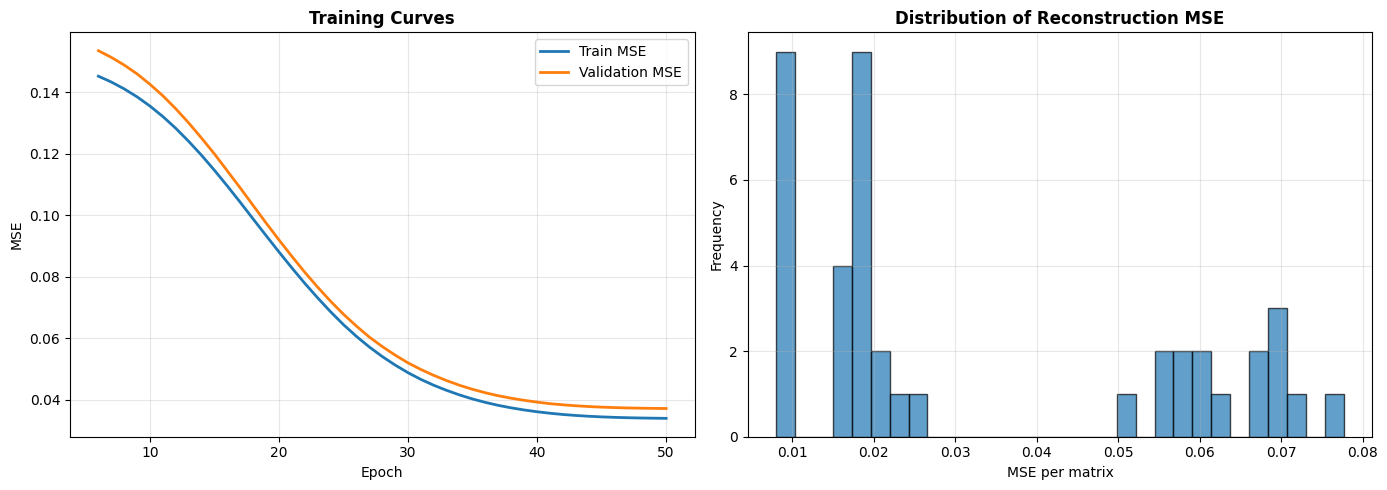

Saved: /content/drive/MyDrive/best_models_tesi/AE/AE_08_more_layer_wd/ae_diagnostics_AE_08_more_layer_wd.png


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_idx = np.arange(1, len(history['train_loss']) + 1)
start_plot = 5  # Skip first 5 epochs

train_loss_plot = np.asarray(history['train_loss'])[start_plot:]
val_loss_plot = np.asarray(history['val_loss'])[start_plot:]
epochs_plot = epochs_idx[start_plot:]

axes[0].plot(epochs_plot, train_loss_plot, label='Train MSE', linewidth=2)
axes[0].plot(epochs_plot, val_loss_plot, label='Validation MSE', linewidth=2)
axes[0].set_title('Training Curves', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].hist(errors_df['MSE'], bins=30, alpha=0.7, color='#1f77b4', edgecolor='black')
axes[1].set_title('Distribution of Reconstruction MSE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('MSE per matrix')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.tight_layout()
diag_path = run_output_dir / f'ae_diagnostics_{RUN}.png'
fig.savefig(diag_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved: {diag_path}')

In [48]:
results_path = run_output_dir / f'ae_results_{RUN}.json'

results_payload = {
    'run': RUN,
    'selected_file': str(selected_file),
    'matrix_range': {
        'start_idx': int(start_idx),
        'end_idx': int(end_idx),
    },
    'model': {
        'latent_dim': int(LATENT_DIM),
        'epochs': int(EPOCHS),
        'lr': float(LR),
        'weight_decay': float(WEIGHT_DECAY),
        'batch_size': int(BATCH_SIZE),
        'scheduler': {
            'type': 'CosineAnnealingLR',
            'T_max': int(COSINE_T_MAX),
            'eta_min': float(COSINE_ETA_MIN),
        },
    },
    'split': {
        'val_ratio': float(VAL_RATIO),
        'test_ratio': float(TEST_RATIO),
        'seed': int(SPLIT_SEED),
        'n_train': int(n_train),
        'n_val': int(n_val),
        'n_test': int(n_test),
    },
    'metrics': {
        'best_validation_mse': float(best_val),
        'test_mse': float(test_loss),
        'reconstruction_stats': errors_stats.to_dict(),
    },
    'loss_history': {
        'train_loss': [float(x) for x in history['train_loss']],
        'val_loss': [float(x) for x in history['val_loss']],
        'lr': [float(x) for x in history['lr']],
    },
    'reconstruction_errors_per_matrix': {
        'MSE': [float(x) for x in errors_df['MSE'].tolist()],
        'MAE': [float(x) for x in errors_df['MAE'].tolist()],
        'Frobenius': [float(x) for x in errors_df['Frobenius'].tolist()],
    },
}

with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results_payload, f, indent=4)

print(f'Saved results: {results_path}')

Saved results: /content/drive/MyDrive/best_models_tesi/AE/AE_08_more_layer_wd/ae_results_AE_08_more_layer_wd.json
